In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import load
import plotly.io as pio
from optuna import visualization as ov
import seaborn as sns

from de_lu_epf.plots.utils import update_matplotlib_params

In [2]:
update_matplotlib_params()

In [3]:
df = pd.read_parquet("../data/processed/processed.parquet")
df_train = df[(df.index.year >= 2019) & (df.index.year < 2024)]
print(df_train.shape)
df_train.head()

(43824, 14)


,precipitation,temperature,relative_humidity,price,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet,24_rmean_price,168_rmean_price,672_rmean_price,24_rvar_price,168_rvar_price,672_rvar_price
datetime,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.250,7.05,92.50,10.07,52750.6,30.6,31.7,-0.605,52.097500,46.054583,48.899777,191.727489,423.445304,431.477251
2019-01-01 01:00:00+00:00,0.100,7.25,91.25,-4.08,51944.2,31.7,32.2,-1.946,49.914167,46.030536,48.847485,323.346417,425.772661,435.183304
2019-01-01 02:00:00+00:00,0.075,7.25,92.25,-9.91,53075.2,33.1,33.3,-1.017,47.589167,45.924286,48.791116,472.607373,435.811931,439.675759
2019-01-01 03:00:00+00:00,0.050,7.05,94.00,-7.41,56323.7,34.1,34.5,-1.964,45.385833,45.805893,48.732649,598.864121,446.133314,443.953378
2019-01-01 04:00:00+00:00,0.000,7.15,93.50,-12.55,56937.8,38.0,37.8,-3.168,42.900000,45.726905,48.654643,738.224261,454.346633,449.427190


/var/folders/j7/fswh0x992tzfxgs898w7vv9w0000gn/T/ipykernel_11315/2600794474.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=xticklabels, size=24)


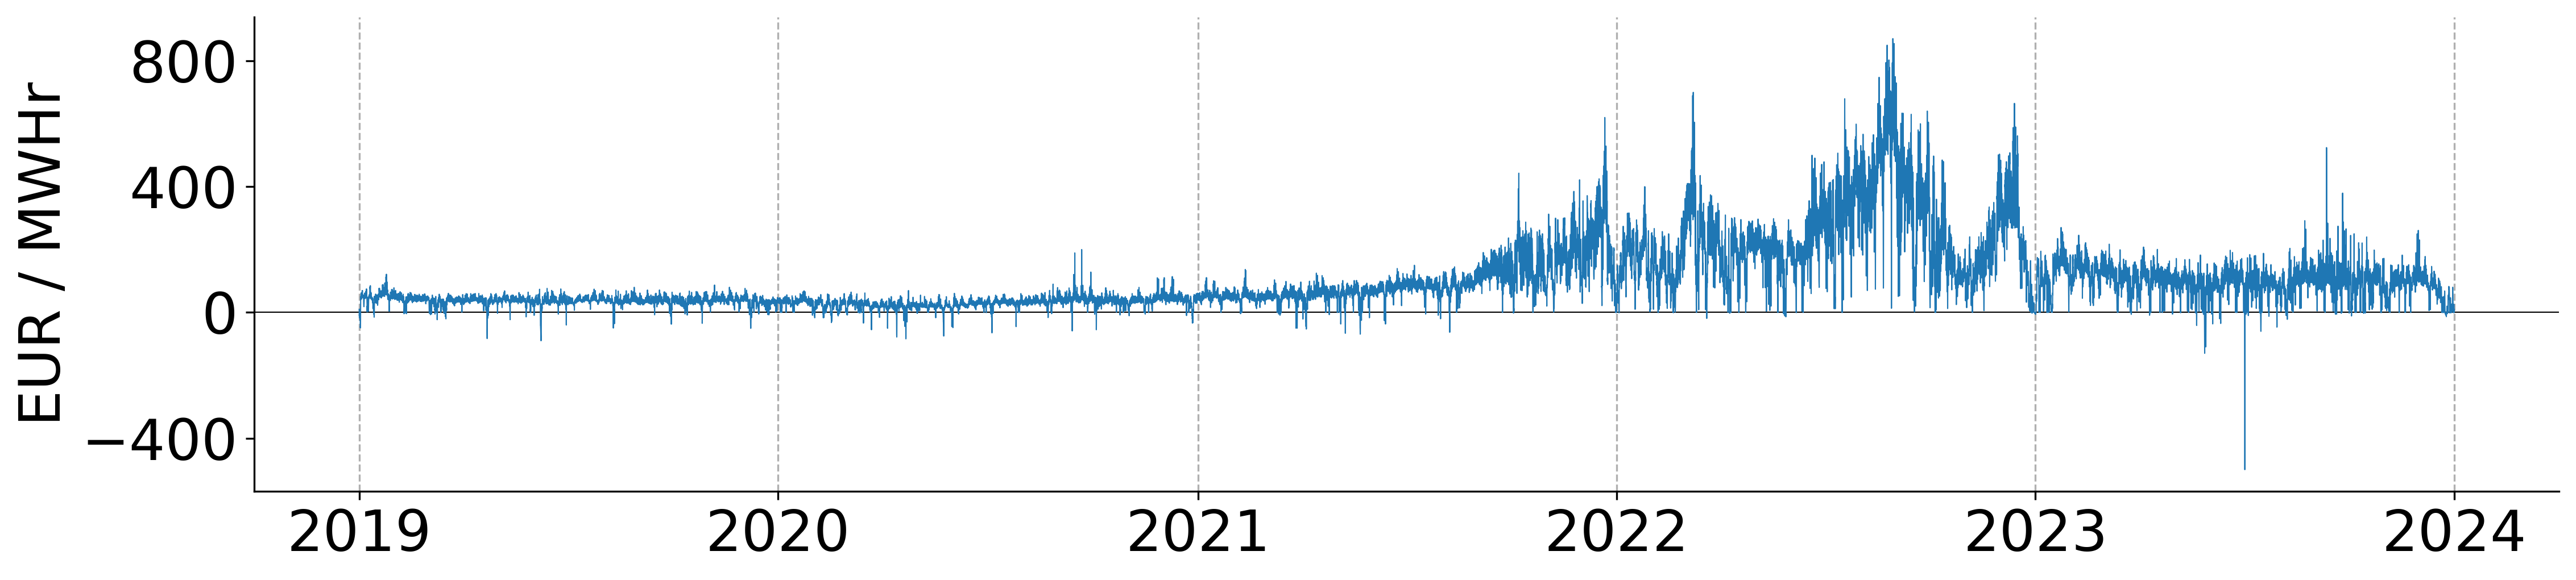

In [44]:
fig, ax = plt.subplots(figsize=(15.2, 3.5), dpi=300)

ax.plot(df_train.index, df_train["price"], c="tab:blue", linewidth=0.5)

ax.axhline(0, color="black", zorder=0, linewidth=0.5)
ax.grid(axis="x", linestyle="--")

xticklabels = ax.get_xticklabels()
ax.set_xticklabels(labels=xticklabels, size=24)

ax.set_yticks([-400, 0, 400, 800])
yticklabels = ax.get_yticklabels()
ax.set_yticklabels(labels=yticklabels, size=24)
ax.set_ylabel("EUR / MWHr", size=24)

# ax.set_title(
#     "Hourly Electricity Prices in the Train Set (2019-2024)", size=24, fontweight="bold"
# )

ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("../../../data_electricity_prices.png")
plt.show()

In [45]:
df_vmd = pd.read_parquet("../data/processed/hybrid/train_val.parquet")
print(df_vmd.shape)
df_vmd.head()

(43822, 20)


,precipitation,temperature,relative_humidity,price,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet,24_rmean_price,168_rmean_price,672_rmean_price,24_rvar_price,168_rvar_price,672_rvar_price,imf1,imf2,imf3,imf4,imf5,imf_resid
datetime,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.250,7.05,92.50,10.07,52750.6,30.6,31.7,-0.605,52.097500,46.054583,48.899777,191.727489,423.445304,431.477251,-4.376678,3.524510,1.362888,1.849468,0.281755,7.428057
2019-01-01 01:00:00+00:00,0.100,7.25,91.25,-4.08,51944.2,31.7,32.2,-1.946,49.914167,46.030536,48.847485,323.346417,425.772661,435.183304,-4.440473,2.303088,0.097638,-1.705119,-0.684297,0.349163
2019-01-01 02:00:00+00:00,0.075,7.25,92.25,-9.91,53075.2,33.1,33.3,-1.017,47.589167,45.924286,48.791116,472.607373,435.811931,439.675759,-4.506713,0.396246,-1.050306,-1.724955,0.884826,-3.909098
2019-01-01 03:00:00+00:00,0.050,7.05,94.00,-7.41,56323.7,34.1,34.5,-1.964,45.385833,45.805893,48.732649,598.864121,446.133314,443.953378,-4.538450,-1.480786,-1.036359,1.570878,-0.887625,-1.037658
2019-01-01 04:00:00+00:00,0.000,7.15,93.50,-12.55,56937.8,38.0,37.8,-3.168,42.900000,45.726905,48.654643,738.224261,454.346633,449.427190,-4.546261,-2.730591,-0.182724,1.483020,0.660493,-7.233936


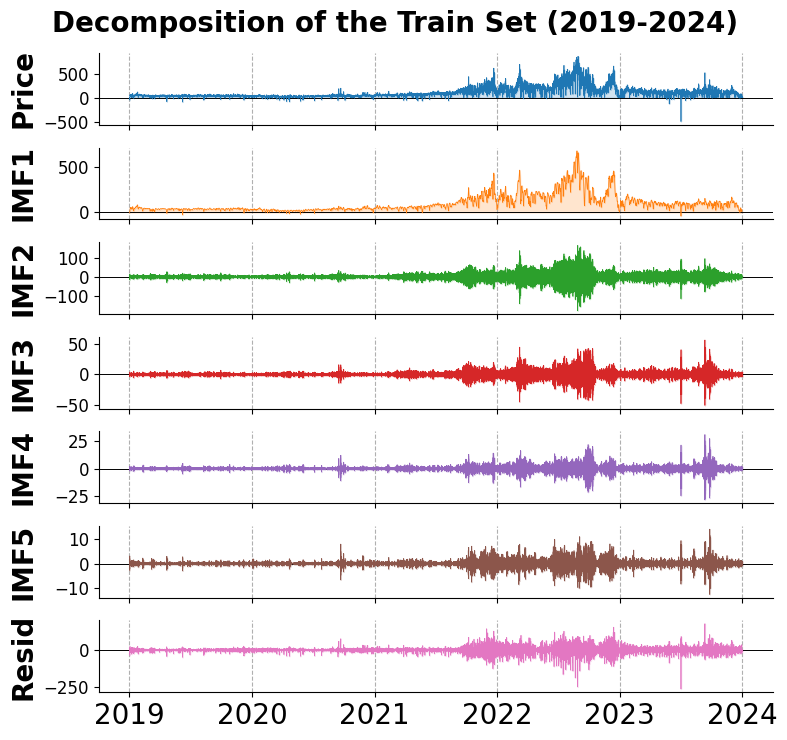

In [66]:
fig, axes = plt.subplots(7, sharex=True, figsize=(8, 7.5))
colors = plt.colormaps["tab10"].colors

ax = axes[0]
ax.axhline(0, linewidth=0.7, color="black")
ax.plot(df_vmd.index, df_vmd["price"], linewidth=0.5, c=colors[0])
ax.fill_between(df_vmd.index, df_vmd["price"], color=colors[0], alpha=0.2)
ax.grid(axis="x", linestyle="--")
ax.set_ylabel("Price", fontsize=20, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=12)

for i, (col, ylab) in enumerate(
    zip(
        ["imf1", "imf2", "imf3", "imf4", "imf5", "imf_resid"],
        ["IMF1", "IMF2", "IMF3", "IMF4", "IMF5", "Resid"],
    )
):
    ax = axes[i + 1]
    ax.axhline(0, linewidth=0.7, color="black")
    ax.plot(df_vmd.index, df_vmd[col], linewidth=0.5, c=colors[i + 1])
    ax.fill_between(df_vmd.index, df_vmd[col], color=colors[i + 1], alpha=0.2)
    ax.grid(axis="x", linestyle="--")
    ax.set_ylabel(ylab, fontsize=20, fontweight="bold")
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=12)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Decomposition of the Train Set (2019-2024)", fontsize=20, fontweight="bold"
)
fig.tight_layout()
fig.align_ylabels()
fig.savefig("../../../methods_vmd.png")
plt.show()

In [3]:
lstm_mha_study = load('../studies/ann/lstm_mha.pkl')

In [4]:
ov.plot_optimization_history(lstm_mha_study)